# Setup & Imports

In [1]:
# Step 1: Upload your kaggle.json
from google.colab import files
files.upload()  # select your kaggle.json file

# Step 2: Place it where Kaggle expects it
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/kaggle.json')
os.system('chmod 600 /root/.kaggle/kaggle.json')

print("✅ Done")

Saving kaggle.json to kaggle.json
✅ Done


In [2]:
# ============================================================
# SETUP: Install required libraries
# ============================================================
# Run this cell once. On a local machine with GPU, tensorflow
# should already be installed. We skip tensorflow-datasets
# since we load the flood dataset from local files.

import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

# Only install if not already present
try:
    import kaggle
except ImportError:
    pip_install('kaggle')

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU:  {torch.cuda.get_device_name(0)}')
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# ============================================================
# Keras 3.x compatibility helper
# ============================================================
def get_layer_shape(layer):
    """Get output shape compatible with both Keras 2.x and 3.x."""
    try:
        return layer.output_shape
    except AttributeError:
        return layer.output.shape


CUDA available: True
GPU:  Tesla T4
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Constants & Configuration

In [3]:
# ============================================================
# CONFIGURATION
# ============================================================
IMG_SIZE = 640    # For full training

BATCH_SIZE = 8               # Reduce to 4 if you get OOM at 640x640
BUFFER_SIZE = 300
NUM_CLASSES = 2              # 0 = Background, 1 = Flood

EPOCHS_SIMPLE = 5    # Quick demo
EPOCHS_FULL   = 35   # Full training (requirement: min 20)

CLASS_NAMES = ['Background', 'Flood']
# Background = blue, Flood = orange
COLORMAP = np.array([[30, 100, 200], [255, 140, 0]], dtype=np.uint8)

# Dataset path — will be set after download
DATA_DIR = './flood_data'
IMAGE_DIR = os.path.join(DATA_DIR, 'Image')
MASK_DIR  = os.path.join(DATA_DIR, 'Mask')

print(f"IMG_SIZE:    {IMG_SIZE}x{IMG_SIZE}")
print(f"BATCH_SIZE:  {BATCH_SIZE}")
print(f"NUM_CLASSES: {NUM_CLASSES} → {CLASS_NAMES}")


IMG_SIZE:    640x640
BATCH_SIZE:  8
NUM_CLASSES: 2 → ['Background', 'Flood']


# Load Dataset

In [4]:
# ============================================================
# Download Flood Area Segmentation dataset via Kaggle API
# ============================================================

import os, zipfile

# Verify kaggle.json exists
kaggle_config = os.path.expanduser('~/.kaggle/kaggle.json')
if not os.path.exists(kaggle_config):
    raise FileNotFoundError(
        f"kaggle.json not found at {kaggle_config}\n"
        "Download it from kaggle.com → Account → API → Create New Token"
    )

os.chmod(kaggle_config, 0o600)  # Secure the file (Linux/Mac)
print(f"✅ kaggle.json found at {kaggle_config}")

# Download (skip if already downloaded)
zip_path = 'flood-area-segmentation.zip'
if not os.path.exists(zip_path):
    print("Downloading dataset from Kaggle...")
    os.system('kaggle datasets download -d faizalkarim/flood-area-segmentation')
    print("✅ Download complete")
else:
    print("✅ Already downloaded — skipping")

# Unzip
if not os.path.exists(DATA_DIR):
    print(f"Unzipping to {DATA_DIR}...")
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
    print("✅ Unzip complete")
else:
    print(f"✅ Already extracted to {DATA_DIR}")

# Verify structure
image_files = sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))
mask_files  = sorted(glob.glob(os.path.join(MASK_DIR, '*')))

print(f"\nDataset structure:")
print(f"  Images: {len(image_files)} files in {IMAGE_DIR}")
print(f"  Masks:  {len(mask_files)} files in {MASK_DIR}")

# Show a few filenames
print(f"\nSample image files: {[os.path.basename(f) for f in image_files[:3]]}")
print(f"Sample mask files:  {[os.path.basename(f) for f in mask_files[:3]]}")


✅ kaggle.json found at /root/.kaggle/kaggle.json
✅ Download complete
Unzipping to ./flood_data...
✅ Unzip complete

Dataset structure:
  Images: 290 files in ./flood_data/Image
  Masks:  290 files in ./flood_data/Mask

Sample image files: ['0.jpg', '1.jpg', '10.jpg']
Sample mask files:  ['0.png', '1.png', '10.png']


In [5]:
import os
import tensorflow as tf
from pathlib import Path

# Configuration
IMAGE_DIR = Path("flood_data/Image")
MASK_DIR = Path("flood_data/Mask")
IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp"]

def cleanup_dataset(image_path, mask_path):
    print(f"--- Starting Cleanup Process ---")

    if not image_path.exists() or not mask_path.exists():
        print("Error: One or both directories do not exist. Check your paths!")
        return

    corrupt_count = 0

    # 1. Iterate through images to find corruption
    for img_file in image_path.rglob("*"):
        if img_file.suffix.lower() in IMAGE_EXTENSIONS:
            is_corrupt = False

            try:
                # Attempt to decode with TensorFlow
                img_bytes = tf.io.read_file(str(img_file))
                tf.io.decode_image(img_bytes, expand_animations=False)
            except Exception:
                is_corrupt = True

            # 2. If corrupt, delete the image AND the matching mask
            if is_corrupt:
                print(f"Corrupt file found: {img_file.name}. Removing pair...")

                # Define possible mask matches (same name, potentially different extension)
                mask_options = [
                    mask_path / img_file.name,
                    mask_path / img_file.with_suffix(".png").name,
                    mask_path / img_file.with_suffix(".jpg").name
                ]

                # Delete the Image
                img_file.unlink()

                # Delete the Mask
                for m_opt in mask_options:
                    if m_opt.exists():
                        m_opt.unlink()
                        print(f"  -> Successfully removed matching mask: {m_opt.name}")
                        break

                corrupt_count += 1

    # 3. Final Report
    print(f"\n--- Cleanup Complete ---")
    print(f"Total pairs removed: {corrupt_count}")

    final_img_count = len(list(image_path.glob('*')))
    final_mask_count = len(list(mask_path.glob('*')))
    print(f"Remaining Images: {final_img_count}")
    print(f"Remaining Masks:  {final_mask_count}")

    if final_img_count != final_mask_count:
        print("Warning: Counts still do not match! Check for extra files in Mask folder.")

# Run the function
cleanup_dataset(IMAGE_DIR, MASK_DIR)

--- Starting Cleanup Process ---
Corrupt file found: 1037.jpg. Removing pair...
  -> Successfully removed matching mask: 1037.png
Corrupt file found: 28.jpg. Removing pair...
  -> Successfully removed matching mask: 28.png
Corrupt file found: 3063.jpg. Removing pair...
  -> Successfully removed matching mask: 3063.png
Corrupt file found: 1036.jpg. Removing pair...
  -> Successfully removed matching mask: 1036.png
Corrupt file found: 3086.jpg. Removing pair...
  -> Successfully removed matching mask: 3086.png
Corrupt file found: 3054.jpg. Removing pair...
  -> Successfully removed matching mask: 3054.png
Corrupt file found: 41.jpg. Removing pair...
  -> Successfully removed matching mask: 41.png
Corrupt file found: 3008.jpg. Removing pair...
  -> Successfully removed matching mask: 3008.png
Corrupt file found: 1077.jpg. Removing pair...
  -> Successfully removed matching mask: 1077.png
Corrupt file found: 19.jpg. Removing pair...
  -> Successfully removed matching mask: 19.png
Corrupt f

# Build Dataset, split train/val/test

In [6]:
# ============================================================
# Match image ↔ mask pairs and do train/val/test split
# ============================================================
# The Flood dataset stores images in Image/ and masks in Mask/
# Filenames correspond: Image/0001.jpg ↔ Mask/0001.png (verify below)

import re

def get_stem(path):
    """Return filename without extension."""
    return os.path.splitext(os.path.basename(path))[0]

# Build matched pairs
image_stems = {get_stem(f): f for f in sorted(glob.glob(os.path.join(IMAGE_DIR, '*')))}
mask_stems  = {get_stem(f): f for f in sorted(glob.glob(os.path.join(MASK_DIR,  '*')))}

common_stems = sorted(set(image_stems.keys()) & set(mask_stems.keys()))
print(f"Matched image-mask pairs: {len(common_stems)}")

image_paths = [image_stems[s] for s in common_stems]
mask_paths  = [mask_stems[s]  for s in common_stems]

# Manual split: 70% train, 15% val, 15% test
n = len(image_paths)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

# Shuffle with fixed seed before splitting
rng = np.random.RandomState(42)
idx = rng.permutation(n)
image_paths = [image_paths[i] for i in idx]
mask_paths  = [mask_paths[i]  for i in idx]

train_imgs, train_masks = image_paths[:n_train],         mask_paths[:n_train]
val_imgs,   val_masks   = image_paths[n_train:n_train+n_val], mask_paths[n_train:n_train+n_val]
test_imgs,  test_masks  = image_paths[n_train+n_val:],   mask_paths[n_train+n_val:]

print(f"\nSplit summary:")
print(f"  Train: {len(train_imgs)} images")
print(f"  Val:   {len(val_imgs)} images")
print(f"  Test:  {len(test_imgs)} images")


Matched image-mask pairs: 249

Split summary:
  Train: 174 images
  Val:   37 images
  Test:  38 images


# Pre Processing

In [7]:
# ============================================================
# Preprocessing: load, resize, normalize image + mask
# ============================================================

def load_image(path):
    """Load and decode a JPEG/PNG image."""
    raw = tf.io.read_file(path)
    # Try JPEG first (images), fallback handles PNG
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img

def load_mask(path):
    """Load and decode a mask image (grayscale)."""
    raw = tf.io.read_file(path)
    msk = tf.image.decode_image(raw, channels=1, expand_animations=False)
    msk.set_shape([None, None, 1])
    return msk

def preprocess(img_path, msk_path):
    """Load, resize, and normalize an image-mask pair.

    Returns:
        image: float32 [IMG_SIZE, IMG_SIZE, 3] in [0, 1]
        mask:  int32   [IMG_SIZE, IMG_SIZE, 1] with values 0 or 1
    """
    image = load_image(img_path)
    mask  = load_mask(msk_path)

    # Resize — NEAREST_NEIGHBOR for mask to preserve binary values
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask  = tf.image.resize(mask,  (IMG_SIZE, IMG_SIZE),
                            method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    # Normalize image to [0, 1]
    image = tf.cast(image, tf.float32) / 255.0

    # Binarize mask: 255 → 1, 0 → 0
    mask = tf.cast(mask > 127, tf.int32)

    return image, mask

# Build tf.data datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_imgs, train_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_imgs, val_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_imgs, test_masks)) \
    .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Verify shapes and dtypes
for image, mask in train_dataset.take(1):
    print(f"Image shape:  {image.shape}, dtype: {image.dtype}")
    print(f"Mask shape:   {mask.shape},  dtype: {mask.dtype}")
    print(f"Image range:  [{image.numpy().min():.2f}, {image.numpy().max():.2f}]")
    print(f"Mask unique values: {np.unique(mask.numpy())}  (expected: [0, 1])")


Image shape:  (640, 640, 3), dtype: <dtype: 'float32'>
Mask shape:   (640, 640, 1),  dtype: <dtype: 'int32'>
Image range:  [0.00, 0.91]
Mask unique values: [0 1]  (expected: [0, 1])


# Explore the Data

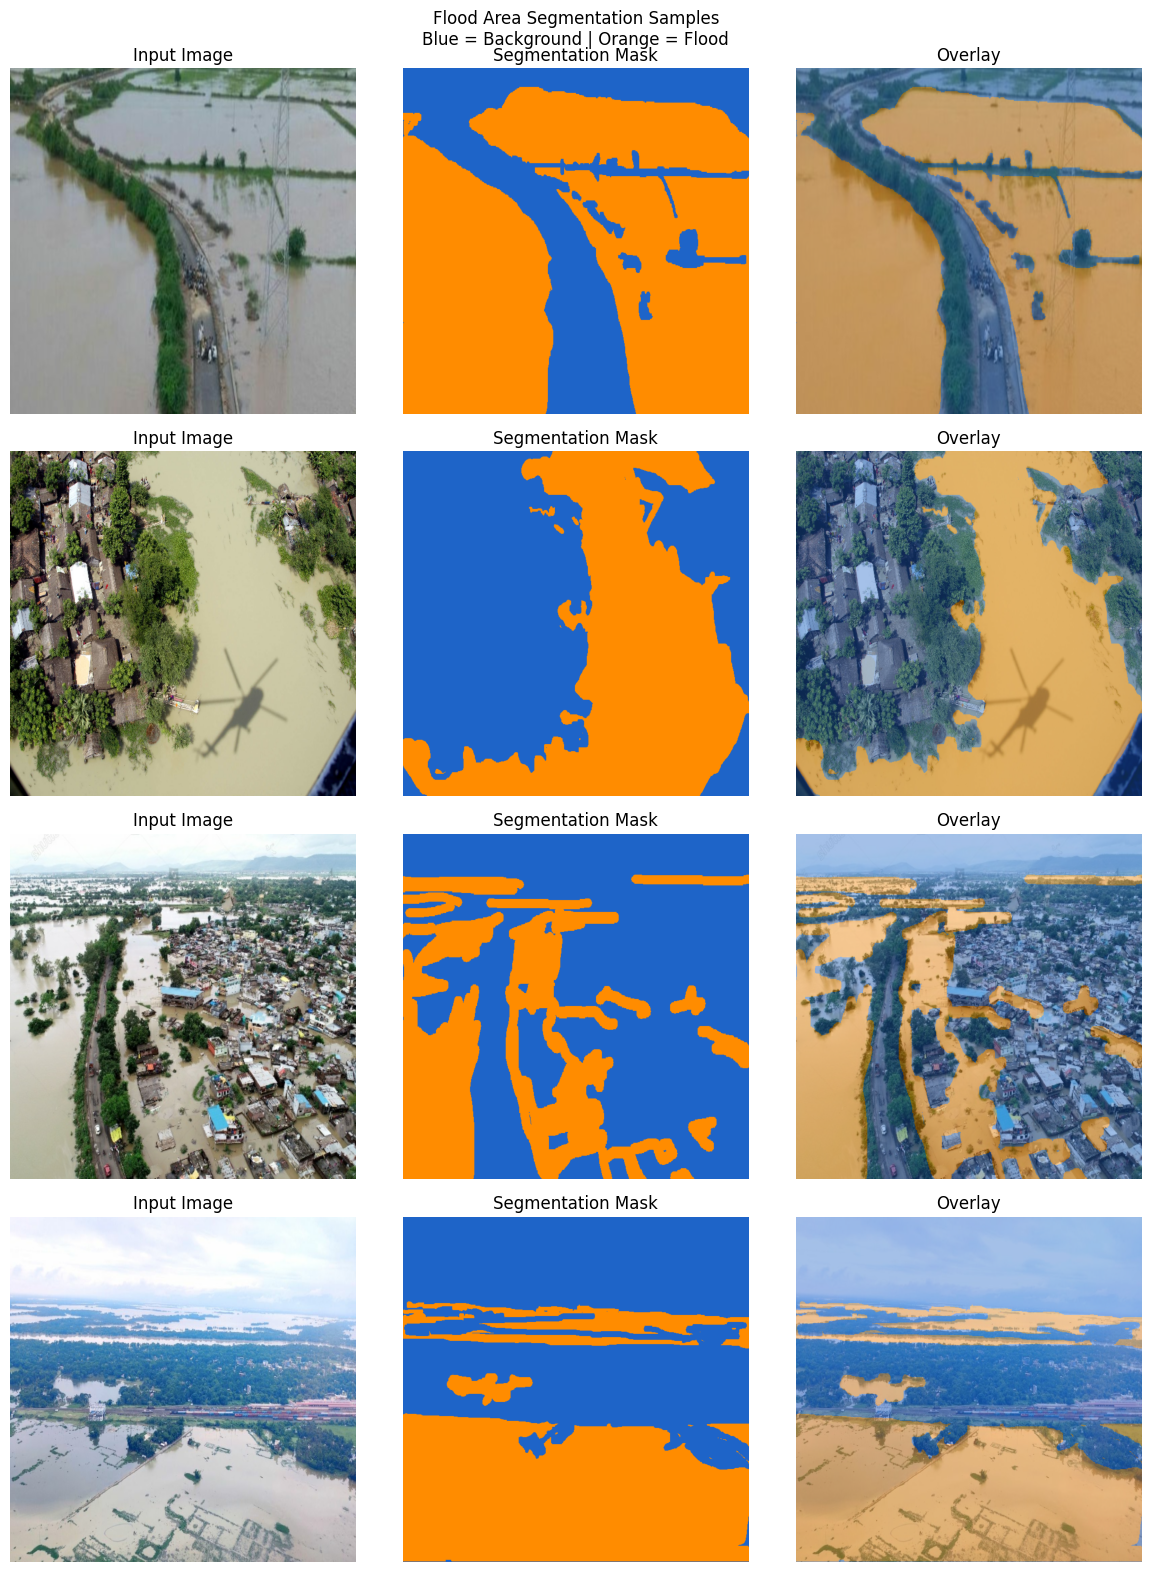

In [8]:
# ============================================================
# Visualize samples: image, mask, and overlay
# ============================================================

def display_sample(images, masks, num_samples=4, title='Flood Area Segmentation Samples'):
    """Display images alongside their flood segmentation masks."""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        mask_colored = COLORMAP[masks[i].squeeze().astype(int)]

        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(mask_colored)
        axes[i, 1].set_title('Segmentation Mask')
        axes[i, 1].axis('off')

        # Semi-transparent overlay
        overlay = np.clip(images[i] * 0.6 + mask_colored / 255.0 * 0.4, 0, 1)
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title('Overlay')
        axes[i, 2].axis('off')

    plt.suptitle(f'{title}\nBlue = Background | Orange = Flood', fontsize=12)
    plt.tight_layout()
    plt.show()

# Collect samples
sample_images, sample_masks = [], []
for img, msk in train_dataset.take(4):
    sample_images.append(img.numpy())
    sample_masks.append(msk.numpy())

display_sample(sample_images, sample_masks)


In [9]:
# ============================================================
# Class distribution analysis
# ============================================================

# Note: Segmentation datasets are often imbalanced.
# Background pixels typically dominate. This matters for loss functions.

class_counts = np.zeros(NUM_CLASSES)
num_analyzed = 0

for image, mask in train_dataset.take(100):  # Analyze first 100 images
    mask_np = mask.numpy().astype(int).flatten()
    for c in range(NUM_CLASSES):
        class_counts[c] += np.sum(mask_np == c)
    num_analyzed += 1

total_pixels = class_counts.sum()
print(f"\nClass distribution (analyzed {num_analyzed} images):")
print(f"{'Class':<15} {'Count':>12} {'Percentage':>10}")
print(f"{'-'*40}")
for i, name in enumerate(CLASS_NAMES):
    pct = class_counts[i] / total_pixels * 100
    print(f"{name:<15} {class_counts[i]:>12,.0f} {pct:>9.1f}%")

# Calculate class weights (inverse frequency)
class_weights = total_pixels / (NUM_CLASSES * class_counts)
print(f"\nSuggested class weights: {dict(zip(CLASS_NAMES, np.round(class_weights, 2)))}")


Class distribution (analyzed 100 images):
Class                  Count Percentage
----------------------------------------
Background        24,058,444      58.7%
Flood             16,901,556      41.3%

Suggested class weights: {'Background': np.float64(0.85), 'Flood': np.float64(1.21)}


# Helper Functions

In [10]:
# ============================================================
# Helper: Encoder block (Conv → Conv → MaxPool)
# ============================================================

# Define reusable building blocks, then assemble the full architecture.

def encoder_block(inputs, num_filters):
    """Encoder block: Conv2D → BN → ReLU → Conv2D → BN → ReLU → MaxPool.
    Returns: skip connection output AND pooled output."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    skip = x  # Save for skip connection BEFORE pooling
    pool = layers.MaxPooling2D(2)(x)

    return skip, pool

def decoder_block(inputs, skip, num_filters):
    """Decoder block: UpConv → Concatenate(skip) → Conv2D → BN → ReLU → Conv2D → BN → ReLU."""
    x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same')(inputs)
    x = layers.Concatenate()([x, skip])  # Skip connection!

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

def bottleneck_block(inputs, num_filters):
    """Bottleneck: Conv2D → BN → ReLU → Conv2D → BN → ReLU (no pooling)."""
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x

print("✅ Building blocks defined: encoder_block, decoder_block, bottleneck_block")

✅ Building blocks defined: encoder_block, decoder_block, bottleneck_block


In [11]:
# ============================================================
# Build SIMPLIFIED U-Net (3 encoder + 3 decoder blocks)
# ============================================================

def build_simple_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Simplified U-Net with 3 encoder/decoder blocks."""
    inputs = layers.Input(shape=input_shape)

    # --- ENCODER (downsampling path) ---
    skip1, pool1 = encoder_block(inputs, 32)   # 256→128
    skip2, pool2 = encoder_block(pool1, 64)     # 128→64
    skip3, pool3 = encoder_block(pool2, 128)    # 64→32

    # --- BOTTLENECK ---
    bn = bottleneck_block(pool3, 256)            # 32×32×256

    # --- DECODER (upsampling path) ---
    d3 = decoder_block(bn, skip3, 128)           # 32→64
    d2 = decoder_block(d3, skip2, 64)            # 64→128
    d1 = decoder_block(d2, skip1, 32)            # 128→256

    # --- OUTPUT ---
    # 1×1 convolution to map to num_classes channels
    outputs = layers.Conv2D(num_classes, 1, activation='softmax', padding='same')(d1)

    model = models.Model(inputs, outputs, name='Simple_UNet')
    return model

# Build and compile
simple_unet = build_simple_unet()
simple_unet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Summary
print(f"\n{'='*50}")
print(f"SIMPLIFIED U-NET SUMMARY")
print(f"{'='*50}")
print(f"Total parameters: {simple_unet.count_params():,}")
print(f"Input shape:  {simple_unet.input_shape}")
print(f"Output shape: {simple_unet.output_shape}")
print(f"\n✅ Output shape matches input spatial dimensions — correct!")
print(f"✅ Output has {NUM_CLASSES} channels (one per class) — correct!")


SIMPLIFIED U-NET SUMMARY
Total parameters: 1,931,266
Input shape:  (None, 640, 640, 3)
Output shape: (None, 640, 640, 2)

✅ Output shape matches input spatial dimensions — correct!
✅ Output has 2 channels (one per class) — correct!


In [12]:
# ============================================================
# Quick training demo (5 epochs) to show it works
# ============================================================

# Quick training demo to verify the architecture works.
# We'll train properly in Task 3 with the full U-Net.

# Prepare quick training batches
train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_batches = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Training simplified U-Net for {EPOCHS_SIMPLE} epochs (quick demo)...")
print(f"This should take ~1-2 minutes on GPU.\n")

simple_history = simple_unet.fit(
    train_batches,
    validation_data=test_batches,
    epochs=EPOCHS_SIMPLE,
    verbose=1
)

Training simplified U-Net for 5 epochs (quick demo)...
This should take ~1-2 minutes on GPU.

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 190s 4s/step - accuracy: 0.7524 - loss: 0.5318 - val_accuracy: 0.4440 - val_loss: 0.7198
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8132 - loss: 0.4220 - val_accuracy: 0.4404 - val_loss: 0.7777
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.8135 - loss: 0.4218 - val_accuracy: 0.5020 - val_loss: 0.6964
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8287 - loss: 0.4034 - val_accuracy: 0.4403 - val_loss: 1.3347
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8382 - loss: 0.3811 - val_accuracy: 0.4406 - val_loss: 1.4341


Simplified U-Net predictions after 5 epochs:


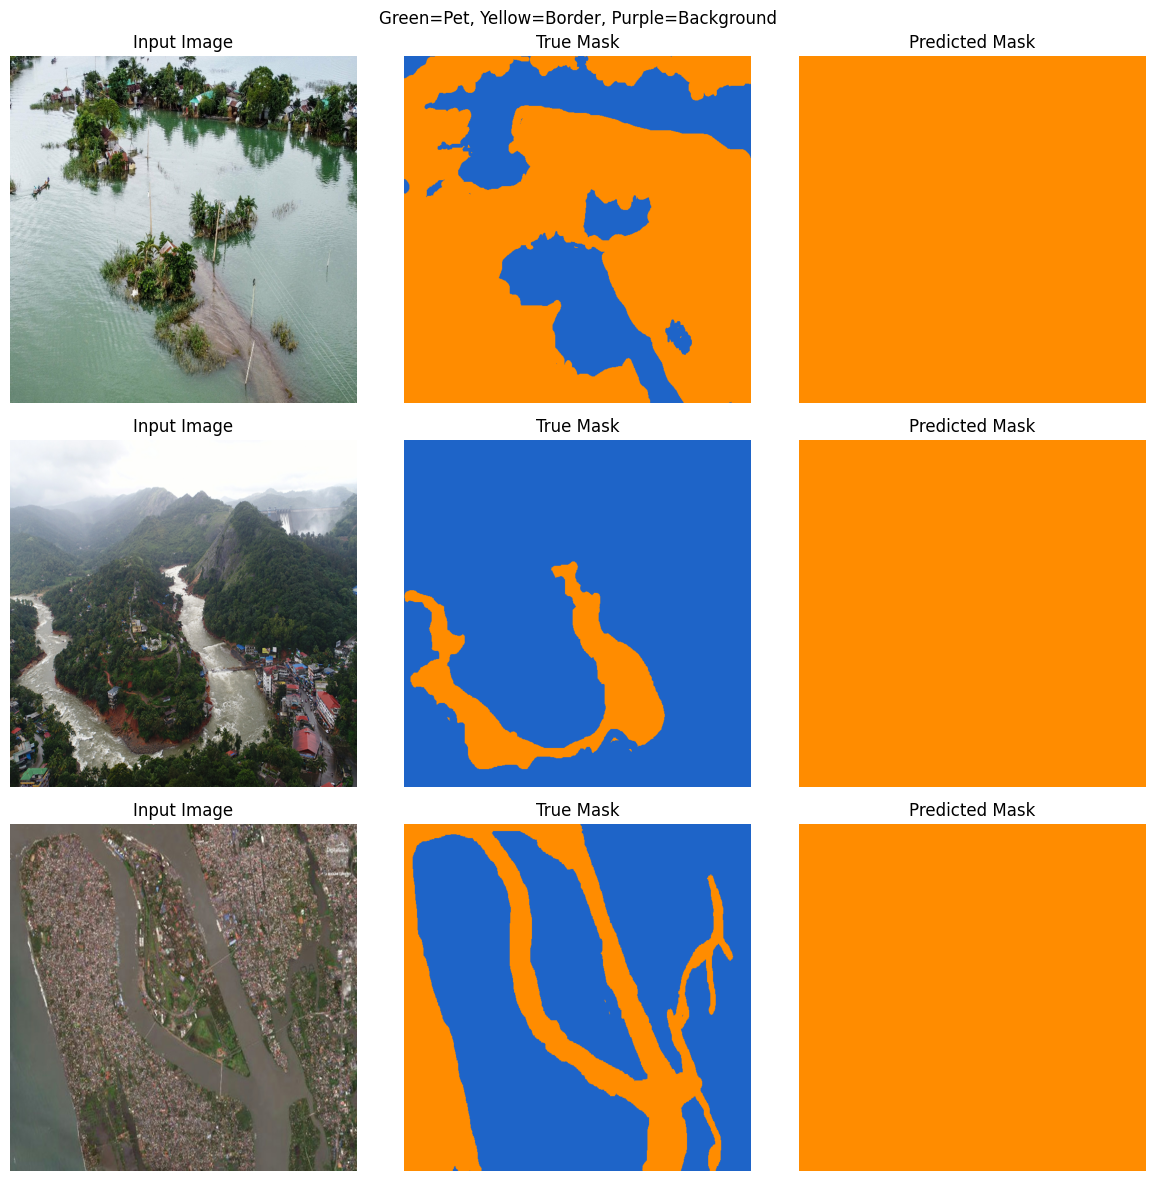

In [13]:
# ============================================================
# Quick prediction visualization
# ============================================================

def show_predictions(model, dataset, num_samples=3):
    """Display image, true mask, and predicted mask side by side."""
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    for i, (image, mask) in enumerate(dataset.take(num_samples)):
        # Get prediction
        pred = model.predict(tf.expand_dims(image, 0), verbose=0)
        pred_mask = tf.argmax(pred[0], axis=-1).numpy()
        true_mask = mask.numpy().squeeze().astype(int)

        # Display
        axes[i, 0].imshow(image.numpy())
        axes[i, 0].set_title('Input Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(COLORMAP[true_mask])
        axes[i, 1].set_title('True Mask')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(COLORMAP[pred_mask])
        axes[i, 2].set_title('Predicted Mask')
        axes[i, 2].axis('off')

    plt.suptitle('Green=Pet, Yellow=Border, Purple=Background', fontsize=12)
    plt.tight_layout()
    plt.show()

print("Simplified U-Net predictions after 5 epochs:")
show_predictions(simple_unet, test_dataset)

# Full U-net Model

In [14]:
# ============================================================
# Build FULL U-Net (4 encoder + 4 decoder blocks)
# ============================================================

def build_full_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Full U-Net with 4 encoder/decoder blocks."""
    inputs = layers.Input(shape=input_shape)
    skip1, pool1 = encoder_block(inputs, 32)
    skip2, pool2 = encoder_block(pool1,  64)
    skip3, pool3 = encoder_block(pool2,  128)
    skip4, pool4 = encoder_block(pool3,  256)
    bottleneck   = bottleneck_block(pool4, 512)
    d4 = decoder_block(bottleneck, skip4, 256)
    d3 = decoder_block(d4,         skip3, 128)
    d2 = decoder_block(d3,         skip2, 64)
    d1 = decoder_block(d2,         skip1, 32)
    outputs = layers.Conv2D(num_classes, 1, activation='softmax', padding='same')(d1)
    return models.Model(inputs, outputs, name='Full_UNet')

print(f"\n{'='*55}")
print(f"MODEL COMPARISON")
print(f"{'='*55}")
print(f"{'Model':<25} {'Parameters':>15} {'Depth':>10}")
print(f"{'-'*55}")

_tmp = build_full_unet()
print(f"{'Simplified U-Net':<25} {simple_unet.count_params():>15,} {'3 blocks':>10}")
print(f"{'Full U-Net':<25} {_tmp.count_params():>15,} {'4 blocks':>10}")
print(f"\nFull U-Net is {_tmp.count_params() / simple_unet.count_params():.1f}x larger")
del _tmp


MODEL COMPARISON
Model                          Parameters      Depth
-------------------------------------------------------
Simplified U-Net                1,931,266   3 blocks
Full U-Net                      7,771,906   4 blocks

Full U-Net is 4.0x larger


In [34]:
# ============================================================
# Dice Loss + Combined Loss — required by project rubric
# ============================================================

def dice_loss(y_true, y_pred, num_classes=NUM_CLASSES, smooth=1e-6):
    """
    Soft Dice Loss for segmentation.
    Operates on softmax probabilities vs one-hot ground truth.
    Better than cross-entropy for imbalanced classes (e.g. small flood regions).
    """
    y_true_oh   = tf.one_hot(tf.squeeze(tf.cast(y_true, tf.int32), axis=-1), num_classes)
    y_true_oh   = tf.cast(y_true_oh, tf.float32)
    y_true_flat = tf.reshape(y_true_oh, [-1, num_classes])
    y_pred_flat = tf.reshape(y_pred,    [-1, num_classes])
    intersection     = tf.reduce_sum(y_true_flat * y_pred_flat, axis=0)
    cardinality      = tf.reduce_sum(y_true_flat + y_pred_flat, axis=0)
    dice_per_class   = (2.0 * intersection + smooth) / (cardinality + smooth)
    return 1.0 - tf.reduce_mean(dice_per_class)

def combined_loss(y_true, y_pred):
    """
    Cross-Entropy + Dice loss.
    CE stabilises early training; Dice improves boundary/imbalance handling.
    """
    ce   = tf.keras.losses.SparseCategoricalCrossentropy()(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return ce + dice

# Model A: Cross-Entropy only (original)
full_unet_ce = build_full_unet()
full_unet_ce.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Model B: Combined CE + Dice loss (new — satisfies rubric requirement)
full_unet_dice = build_full_unet()
full_unet_dice.compile(
    optimizer='adam',
    loss=combined_loss,
    metrics=['accuracy']
)

print("✅ Dice loss function defined")
print("✅ Model A (CE loss)         compiled — full_unet_ce")
print("✅ Model B (CE + Dice loss)  compiled — full_unet_dice")

✅ Dice loss function defined
✅ Model A (CE loss)         compiled — full_unet_ce
✅ Model B (CE + Dice loss)  compiled — full_unet_dice


In [16]:
# ============================================================
# Data augmentation + FIXED train/val/test pipelines
# ============================================================
# FIXED: val_batched uses val_dataset; test_batched is held out until final eval

def augment(image, mask):
    """Synchronized augmentation — spatial transforms applied to BOTH, colour to image only."""
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    image = tf.image.random_brightness(image, 0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

# 640x640 pipelines
train_augmented = (
    train_dataset
    .cache()
    .shuffle(BUFFER_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_batched = (                          # ← used as validation_data during fit()
    val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_batched = (                         # ← held out; only used for final evaluation
    test_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("✅ train_augmented : training   (augmented, 640×640)")
print("✅ val_batched     : validation (no augmentation — used in fit)")
print("✅ test_batched    : test       (no augmentation — final eval only)")

✅ train_augmented : training   (augmented, 640×640)
✅ val_batched     : validation (no augmentation — used in fit)
✅ test_batched    : test       (no augmentation — final eval only)


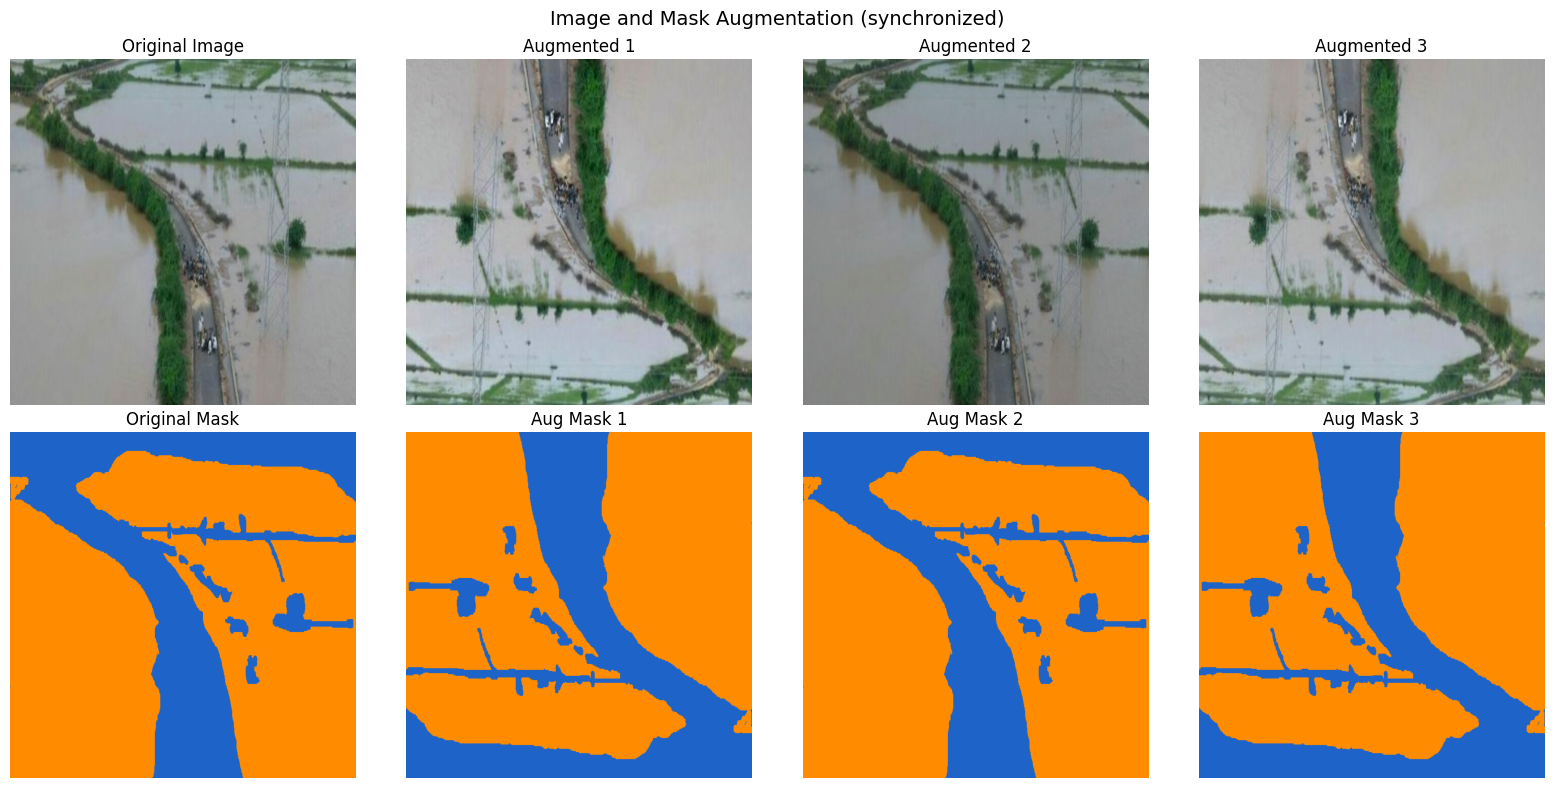

In [17]:
# ============================================================
# Visualize augmentation effects
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for img, msk in train_dataset.take(1):
    original_img, original_msk = img, msk

axes[0, 0].imshow(original_img.numpy()); axes[0, 0].set_title('Original Image'); axes[0, 0].axis('off')
axes[1, 0].imshow(COLORMAP[original_msk.numpy().squeeze().astype(int)]); axes[1, 0].set_title('Original Mask'); axes[1, 0].axis('off')

for i in range(1, 4):
    aug_img, aug_msk = augment(original_img, original_msk)
    axes[0, i].imshow(aug_img.numpy()); axes[0, i].set_title(f'Augmented {i}'); axes[0, i].axis('off')
    axes[1, i].imshow(COLORMAP[aug_msk.numpy().squeeze().astype(int)]); axes[1, i].set_title(f'Aug Mask {i}'); axes[1, i].axis('off')

plt.suptitle('Image and Mask Augmentation (synchronized)', fontsize=14)
plt.tight_layout()
plt.show()

# Train, Evaluate & Visualize

In [36]:
# ============================================================
# Train full U-Net with callbacks
# ============================================================

import os
os.makedirs("checkpoints", exist_ok=True)

def make_callbacks(ckpt_path):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True,
            verbose=1,
            min_delta=0.01
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=8, min_lr=1e-7, verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=ckpt_path, monitor='val_loss',
            save_best_only=True, verbose=1
        )
    ]

tf.keras.utils.set_random_seed(42)

In [37]:
ce_history = full_unet_ce.fit(
    train_augmented,
    validation_data=val_batched,
    epochs=EPOCHS_FULL,
    callbacks=make_callbacks('checkpoints/unet_ce_best.keras'),
    verbose=1
)

Epoch 1/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8086 - loss: 0.4265
Epoch 1: val_loss improved from inf to 1.98117, saving model to checkpoints/unet_ce_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8094 - loss: 0.4254 - val_accuracy: 0.3946 - val_loss: 1.9812 - learning_rate: 5.0000e-04
Epoch 2/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8416 - loss: 0.3720
Epoch 2: val_loss improved from 1.98117 to 1.90928, saving model to checkpoints/unet_ce_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8413 - loss: 0.3726 - val_accuracy: 0.3946 - val_loss: 1.9093 - learning_rate: 5.0000e-04
Epoch 3/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8388 - loss: 0.3766
Epoch 3: val_loss did not improve from 1.90928
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8388 - loss: 0.3762 - val_accuracy: 0.3949 - val_loss: 2.0722 - learning_rate: 5.0000e-04
Epoch 4/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8487 - loss: 0.357

In [38]:
dice_history = full_unet_dice.fit(
    train_augmented,
    validation_data=val_batched,
    epochs=EPOCHS_FULL,
    callbacks=make_callbacks('checkpoints/unet_dice_best.keras'),
    verbose=1
)

Epoch 1/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7318 - loss: 0.8821
Epoch 1: val_loss improved from inf to 1.57350, saving model to checkpoints/unet_dice_best.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.7337 - loss: 0.8779 - val_accuracy: 0.3946 - val_loss: 1.5735 - learning_rate: 0.0010
Epoch 2/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8039 - loss: 0.7245
Epoch 2: val_loss did not improve from 1.57350
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.8037 - loss: 0.7248 - val_accuracy: 0.3946 - val_loss: 2.2957 - learning_rate: 0.0010
Epoch 3/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8082 - loss: 0.6984
Epoch 3: val_loss did not improve from 1.57350
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.8087 - loss: 0.6969 - val_accuracy: 0.3946 - val_loss: 29.6042 - learning_rate: 0.0010
Epoch 4/35
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8235 - loss: 0.6602
Epoch 4: val_loss did not improve from 1.57350
22/22 ━━━━━━

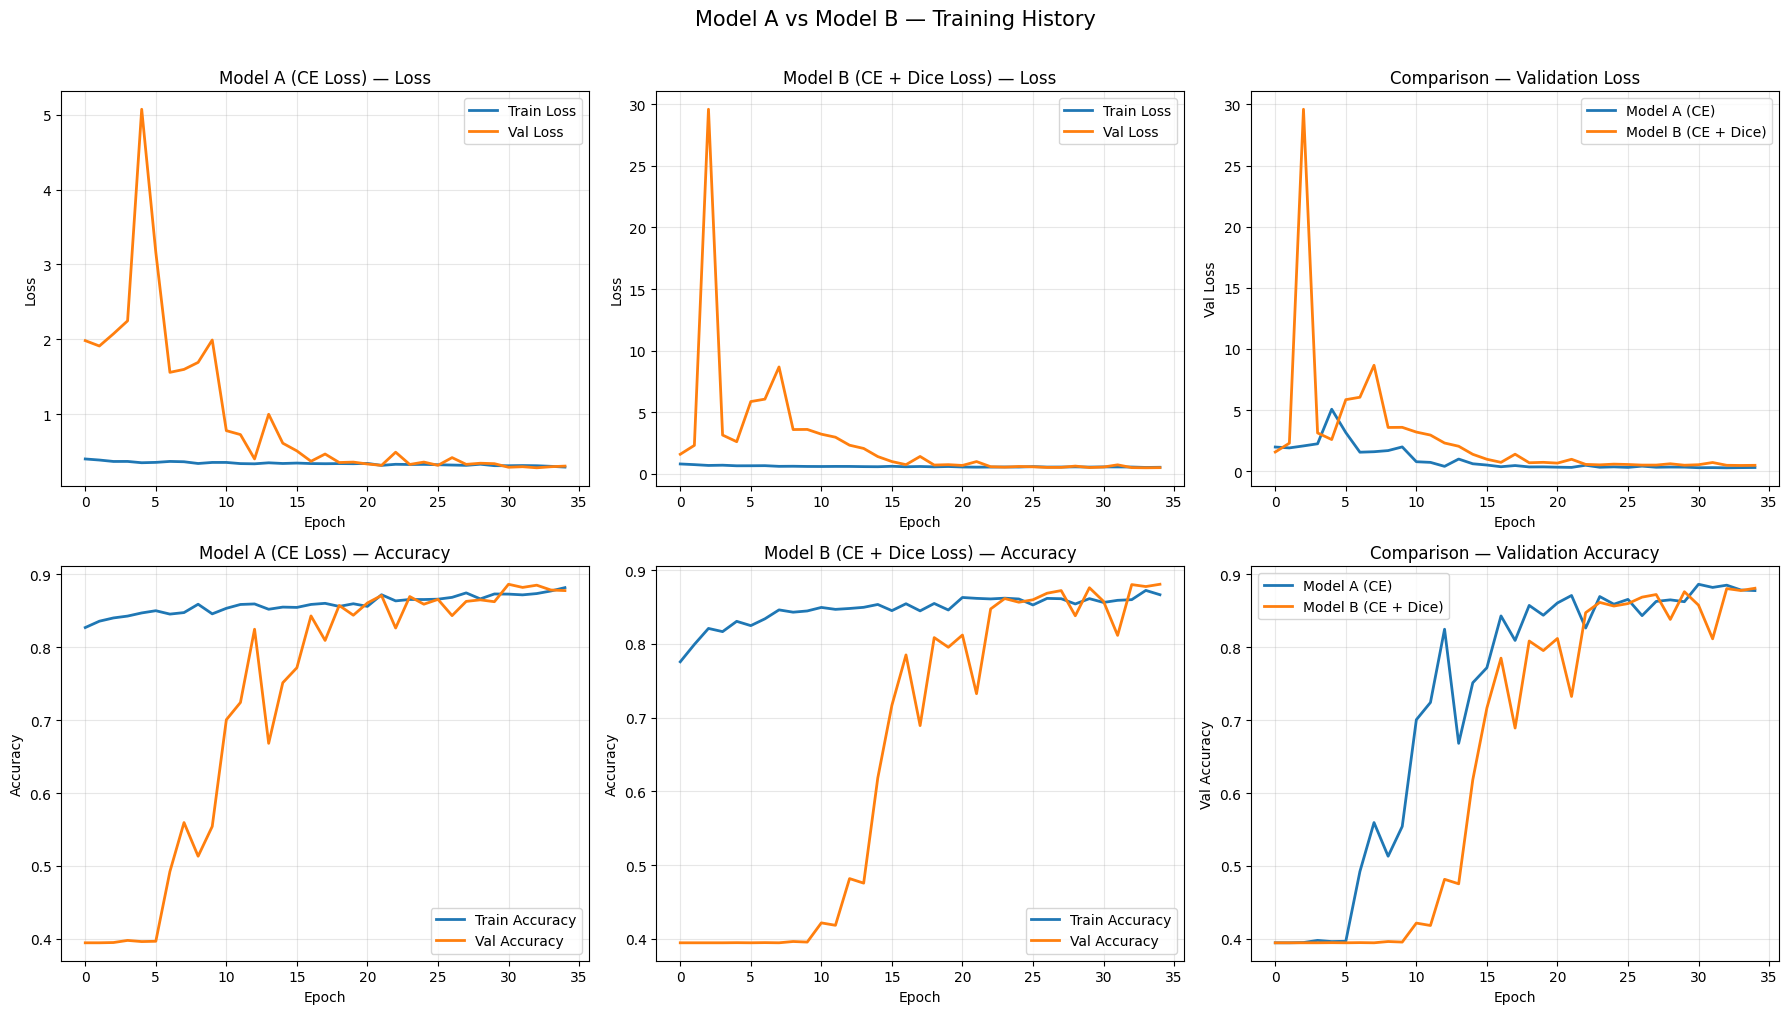


  FINAL EPOCH SUMMARY
Metric                         Model A (CE) Model B (Dice)
-------------------------------------------------------
Final Train Loss                     0.2919         0.5148
Final Val Loss                       0.3049         0.4849
Final Train Accuracy                 0.8818         0.8667
Final Val Accuracy                   0.8777         0.8809
Epochs Trained                           35             35


In [39]:
# ============================================================
# Plot training history — Model A (CE) vs Model B (CE + Dice)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Loss plots ---

# Model A loss
axes[0, 0].plot(ce_history.history['loss'],     label='Train Loss', linewidth=2)
axes[0, 0].plot(ce_history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0, 0].set_title('Model A (CE Loss) — Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Model B loss
axes[0, 1].plot(dice_history.history['loss'],     label='Train Loss', linewidth=2)
axes[0, 1].plot(dice_history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0, 1].set_title('Model B (CE + Dice Loss) — Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Comparison — val loss only
axes[0, 2].plot(ce_history.history['val_loss'],   label='Model A (CE)',        linewidth=2)
axes[0, 2].plot(dice_history.history['val_loss'], label='Model B (CE + Dice)', linewidth=2)
axes[0, 2].set_title('Comparison — Validation Loss')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Val Loss')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# --- Row 2: Accuracy plots ---

# Model A accuracy
axes[1, 0].plot(ce_history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[1, 0].plot(ce_history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[1, 0].set_title('Model A (CE Loss) — Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Model B accuracy
axes[1, 1].plot(dice_history.history['accuracy'],     label='Train Accuracy', linewidth=2)
axes[1, 1].plot(dice_history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
axes[1, 1].set_title('Model B (CE + Dice Loss) — Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Comparison — val accuracy only
axes[1, 2].plot(ce_history.history['val_accuracy'],   label='Model A (CE)',        linewidth=2)
axes[1, 2].plot(dice_history.history['val_accuracy'], label='Model B (CE + Dice)', linewidth=2)
axes[1, 2].set_title('Comparison — Validation Accuracy')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Val Accuracy')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Model A vs Model B — Training History', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# --- Summary table ---
print(f"\n{'='*55}")
print(f"  FINAL EPOCH SUMMARY")
print(f"{'='*55}")
print(f"{'Metric':<30} {'Model A (CE)':>12} {'Model B (Dice)':>14}")
print(f"{'-'*55}")
print(f"{'Final Train Loss':<30} {ce_history.history['loss'][-1]:>12.4f} {dice_history.history['loss'][-1]:>14.4f}")
print(f"{'Final Val Loss':<30} {ce_history.history['val_loss'][-1]:>12.4f} {dice_history.history['val_loss'][-1]:>14.4f}")
print(f"{'Final Train Accuracy':<30} {ce_history.history['accuracy'][-1]:>12.4f} {dice_history.history['accuracy'][-1]:>14.4f}")
print(f"{'Final Val Accuracy':<30} {ce_history.history['val_accuracy'][-1]:>12.4f} {dice_history.history['val_accuracy'][-1]:>14.4f}")
print(f"{'Epochs Trained':<30} {len(ce_history.history['loss']):>12} {len(dice_history.history['loss']):>14}")

In [40]:
# ============================================================
# IoU and Dice Score metric functions
# ============================================================

def compute_iou_per_class(y_true, y_pred, num_classes=NUM_CLASSES):
    """IoU = TP / (TP + FP + FN) for each class."""
    ious = []
    for c in range(num_classes):
        true_c = (y_true == c)
        pred_c = (y_pred == c)
        intersection = np.logical_and(true_c, pred_c).sum()
        union        = np.logical_or(true_c,  pred_c).sum()
        ious.append(float('nan') if union == 0 else intersection / union)
    return ious

def compute_dice_per_class(y_true, y_pred, num_classes=NUM_CLASSES):
    """Dice = 2*TP / (2*TP + FP + FN) for each class."""
    dices = []
    for c in range(num_classes):
        true_c = (y_true == c)
        pred_c = (y_pred == c)
        intersection = np.logical_and(true_c, pred_c).sum()
        total        = true_c.sum() + pred_c.sum()
        dices.append(float('nan') if total == 0 else 2 * intersection / total)
    return dices

print("✅ IoU and Dice metric functions defined")

✅ IoU and Dice metric functions defined


In [41]:
# ============================================================
# Evaluate BOTH models on held-out test set
# ============================================================

def evaluate_model(model, model_name, dataset):
    """Run full evaluation and return per-class IoU/Dice + mIoU."""
    all_ious, all_dices = [], []
    for images, masks in dataset:
        preds      = model.predict(images, verbose=0)
        pred_masks = tf.argmax(preds, axis=-1).numpy()
        true_masks = masks.numpy().squeeze(axis=-1).astype(int)
        for i in range(pred_masks.shape[0]):
            all_ious.append(compute_iou_per_class(true_masks[i], pred_masks[i]))
            all_dices.append(compute_dice_per_class(true_masks[i], pred_masks[i]))

    all_ious   = np.array(all_ious)
    all_dices  = np.array(all_dices)
    mean_ious  = np.nanmean(all_ious,  axis=0)
    mean_dices = np.nanmean(all_dices, axis=0)
    miou       = np.nanmean(mean_ious)
    mdice      = np.nanmean(mean_dices)

    print(f"\n{'='*60}")
    print(f"  {model_name.upper()}")
    print(f"{'='*60}")
    print(f"{'Class':<15} {'IoU':>10} {'Dice':>10}")
    print(f"{'-'*38}")
    for i, name in enumerate(CLASS_NAMES):
        print(f"{name:<15} {mean_ious[i]:>10.4f} {mean_dices[i]:>10.4f}")
    print(f"{'-'*38}")
    print(f"{'Mean (mIoU)':<15} {miou:>10.4f} {mdice:>10.4f}")
    print(f"\n✅ mIoU: {miou:.4f}  |  Mean Dice: {mdice:.4f}")

    return all_ious, all_dices, mean_ious, mean_dices, miou, mdice

print("Evaluating on TEST SET (held-out)...\n")
ce_all_ious,   ce_all_dices,   ce_mean_ious,   ce_mean_dices,   ce_miou,   ce_mdice   = evaluate_model(full_unet_ce,   "Cross-Entropy Loss Model", test_batched)
dice_all_ious, dice_all_dices, dice_mean_ious, dice_mean_dices, dice_miou, dice_mdice = evaluate_model(full_unet_dice, "CE + Dice Loss Model",     test_batched)

print(f"\n{'='*55}")
print(f"  LOSS FUNCTION COMPARISON SUMMARY")
print(f"{'='*55}")
print(f"{'Model':<25} {'mIoU':>10} {'Mean Dice':>12}")
print(f"{'-'*50}")
print(f"{'Cross-Entropy':<25} {ce_miou:>10.4f} {ce_mdice:>12.4f}")
print(f"{'CE + Dice':<25} {dice_miou:>10.4f} {dice_mdice:>12.4f}")
winner = 'CE + Dice' if dice_miou > ce_miou else 'Cross-Entropy'
print(f"\n Better model by mIoU: {winner}")

Evaluating on TEST SET (held-out)...


  CROSS-ENTROPY LOSS MODEL
Class                  IoU       Dice
--------------------------------------
Background          0.7824     0.8712
Flood               0.7024     0.8022
--------------------------------------
Mean (mIoU)         0.7424     0.8367

✅ mIoU: 0.7424  |  Mean Dice: 0.8367



  CE + DICE LOSS MODEL
Class                  IoU       Dice
--------------------------------------
Background          0.7675     0.8617
Flood               0.6659     0.7672
--------------------------------------
Mean (mIoU)         0.7167     0.8144

✅ mIoU: 0.7167  |  Mean Dice: 0.8144

  LOSS FUNCTION COMPARISON SUMMARY
Model                           mIoU    Mean Dice
--------------------------------------------------
Cross-Entropy                 0.7424       0.8367
CE + Dice                     0.7167       0.8144

 Better model by mIoU: Cross-Entropy


Full U-Net (CE + Dice) — detailed predictions:


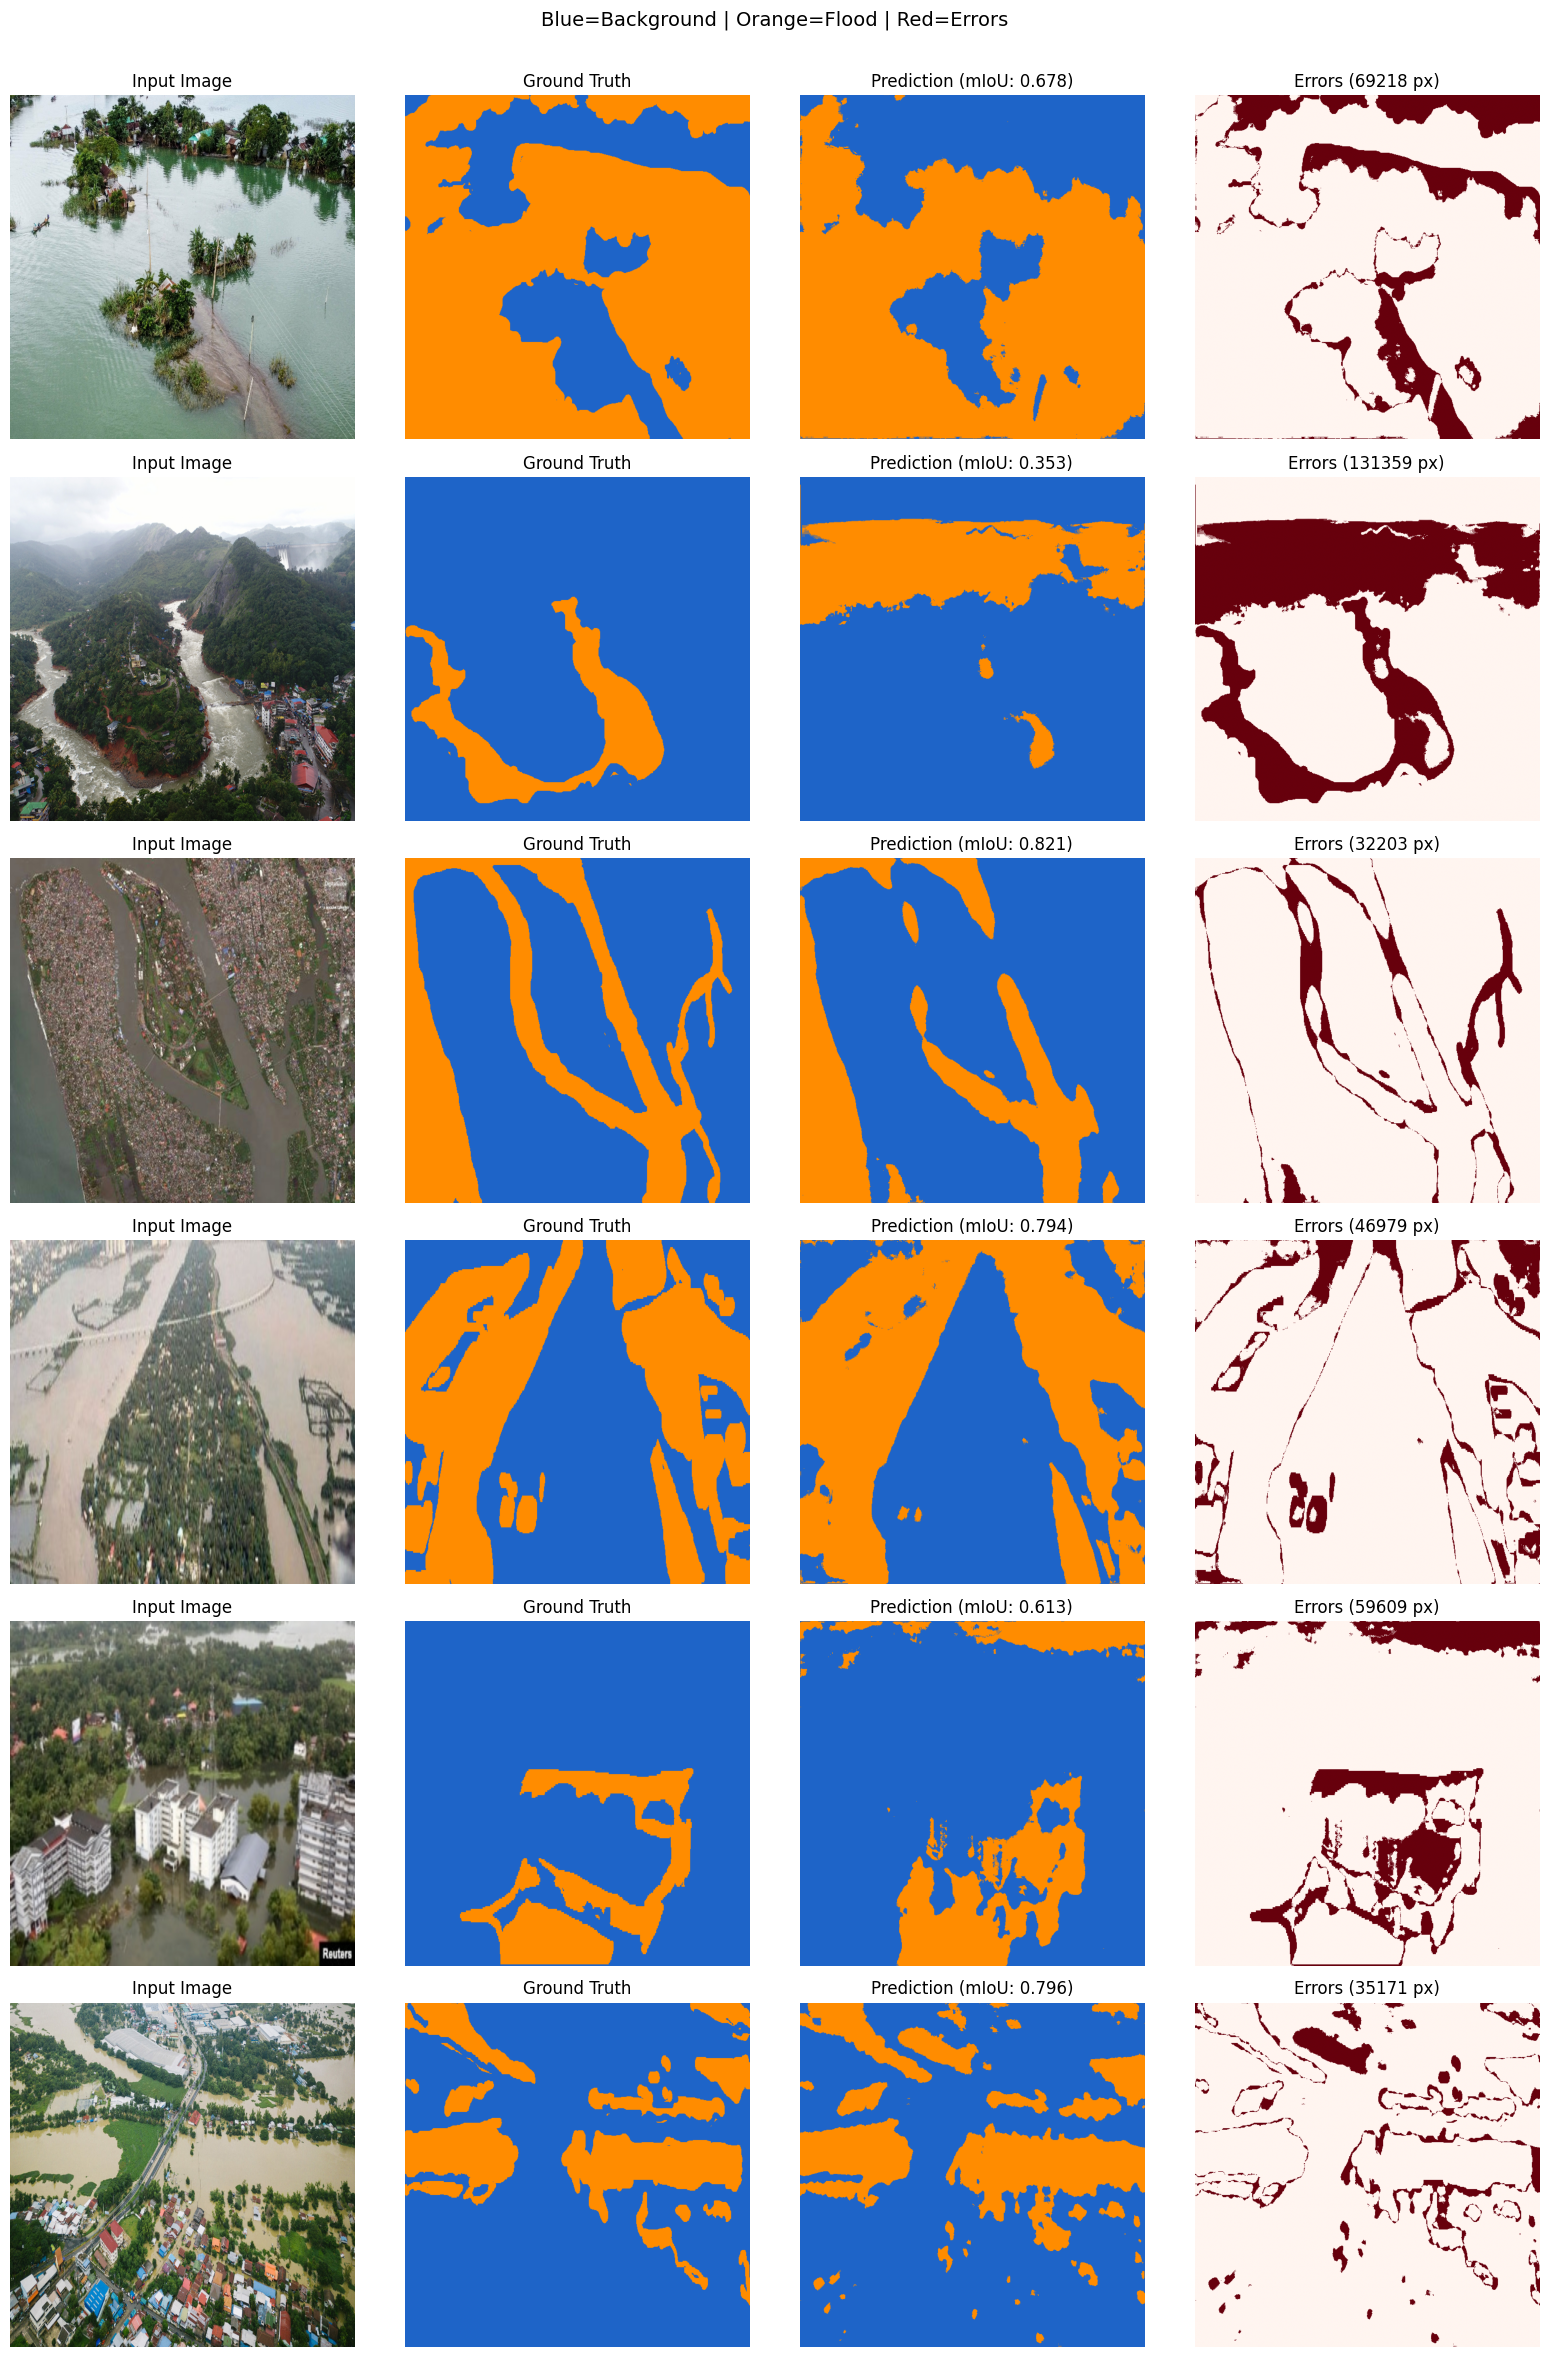

In [42]:
# ============================================================
# Detailed prediction visualization with error maps (6 samples)
# ============================================================

def show_detailed_predictions(model, dataset, num_samples=6):
    """Show input, ground truth, prediction, and error map."""
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    for i, (image, mask) in enumerate(dataset.take(num_samples)):
        pred      = model.predict(tf.expand_dims(image, 0), verbose=0)
        pred_mask = tf.argmax(pred[0], axis=-1).numpy()
        true_mask = mask.numpy().squeeze().astype(int)
        error_map = (pred_mask != true_mask).astype(float)
        mean_iou  = np.nanmean(compute_iou_per_class(true_mask, pred_mask))

        axes[i, 0].imshow(image.numpy());          axes[i, 0].set_title('Input Image');                      axes[i, 0].axis('off')
        axes[i, 1].imshow(COLORMAP[true_mask]);    axes[i, 1].set_title('Ground Truth');                     axes[i, 1].axis('off')
        axes[i, 2].imshow(COLORMAP[pred_mask]);    axes[i, 2].set_title(f'Prediction (mIoU: {mean_iou:.3f})'); axes[i, 2].axis('off')
        axes[i, 3].imshow(error_map, cmap='Reds'); axes[i, 3].set_title(f'Errors ({error_map.sum():.0f} px)');  axes[i, 3].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.suptitle('Blue=Background | Orange=Flood | Red=Errors', fontsize=14, y=0.98)
    plt.show()

print("Full U-Net (CE + Dice) — detailed predictions:")
show_detailed_predictions(full_unet_dice, test_dataset)

/tmp/ipykernel_358/719712962.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(iou_data,  labels=CLASS_NAMES, patch_artist=True)
/tmp/ipykernel_358/719712962.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(dice_data, labels=CLASS_NAMES, patch_artist=True)


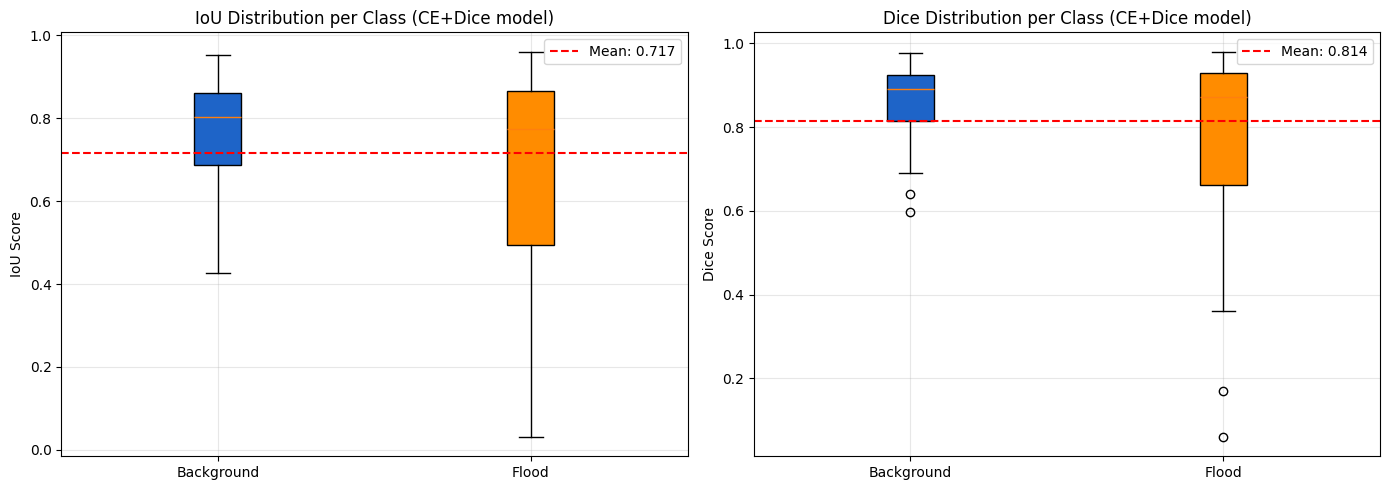

In [43]:
# ============================================================
# Per-class IoU / Dice distribution (box plots)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1e64c8', '#ff8c00']

iou_data  = [dice_all_ious[:,  c][~np.isnan(dice_all_ious[:,  c])] for c in range(NUM_CLASSES)]
dice_data = [dice_all_dices[:, c][~np.isnan(dice_all_dices[:, c])] for c in range(NUM_CLASSES)]

bp1 = axes[0].boxplot(iou_data,  labels=CLASS_NAMES, patch_artist=True)
bp2 = axes[1].boxplot(dice_data, labels=CLASS_NAMES, patch_artist=True)
for bp in [bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

axes[0].set_ylabel('IoU Score');  axes[0].set_title('IoU Distribution per Class (CE+Dice model)')
axes[1].set_ylabel('Dice Score'); axes[1].set_title('Dice Distribution per Class (CE+Dice model)')
for ax, val in zip(axes, [dice_miou, dice_mdice]):
    ax.axhline(y=val, color='red', linestyle='--', label=f'Mean: {val:.3f}')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

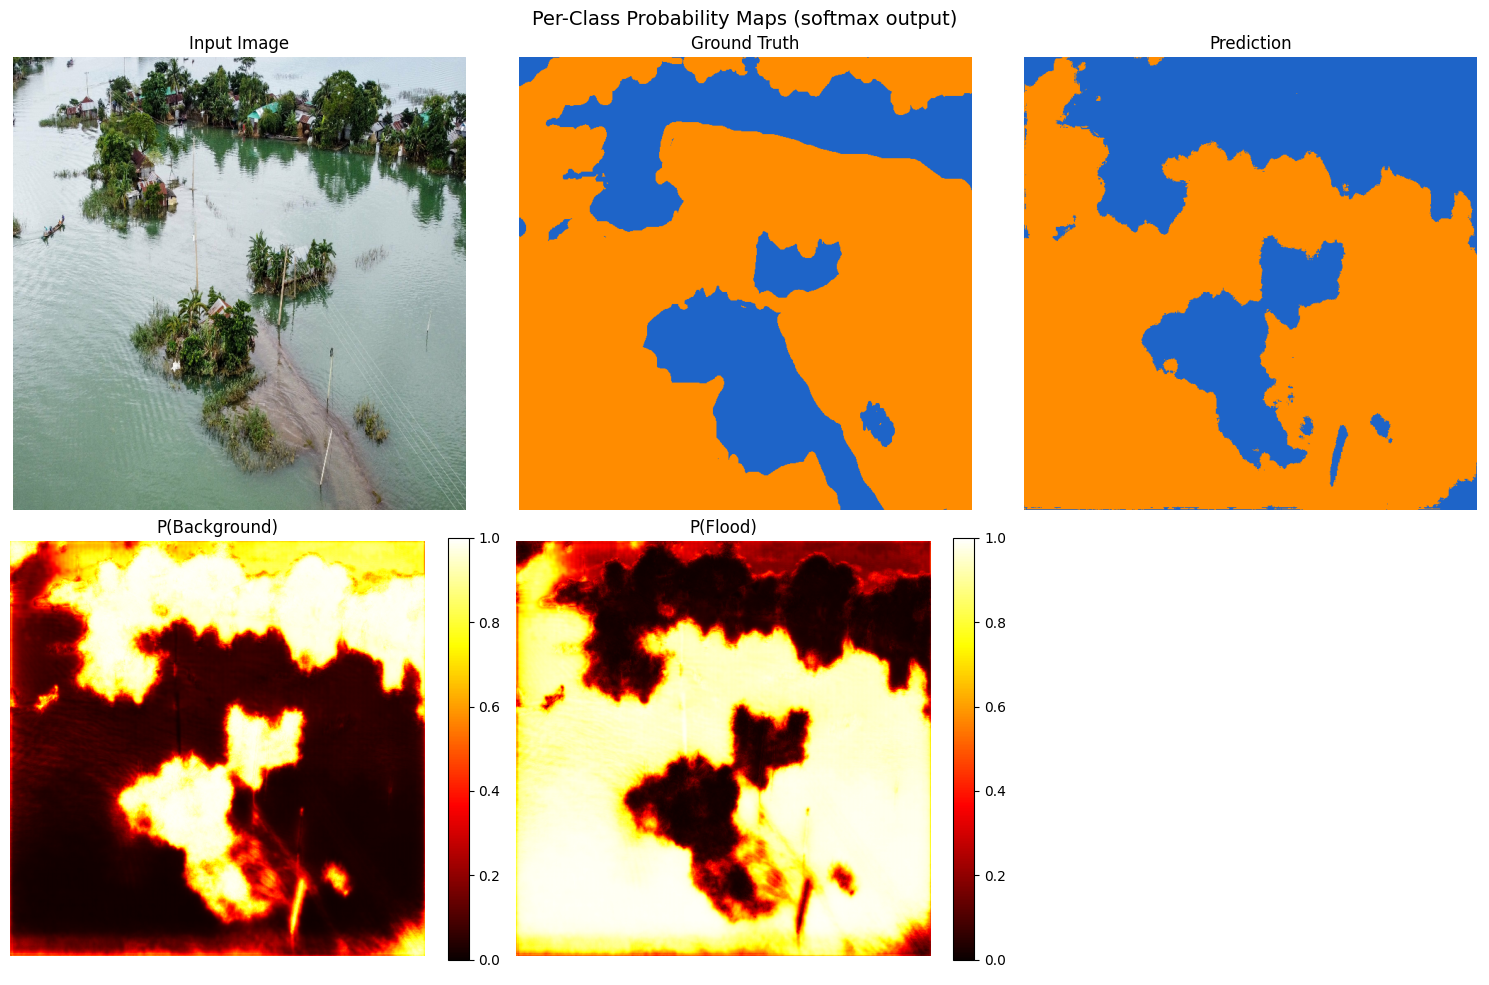

In [44]:
# ============================================================
# Confidence / probability map visualization
# ============================================================

for image, mask in test_dataset.take(1):
    pred      = full_unet_dice.predict(tf.expand_dims(image, 0), verbose=0)[0]
    pred_mask = tf.argmax(pred, axis=-1).numpy()
    true_mask = mask.numpy().squeeze().astype(int)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(image.numpy());        axes[0, 0].set_title('Input Image');  axes[0, 0].axis('off')
axes[0, 1].imshow(COLORMAP[true_mask]);  axes[0, 1].set_title('Ground Truth'); axes[0, 1].axis('off')
axes[0, 2].imshow(COLORMAP[pred_mask]);  axes[0, 2].set_title('Prediction');   axes[0, 2].axis('off')

for c in range(NUM_CLASSES):
    im = axes[1, c].imshow(pred[:, :, c], cmap='hot', vmin=0, vmax=1)
    axes[1, c].set_title(f'P({CLASS_NAMES[c]})')
    axes[1, c].axis('off')
    plt.colorbar(im, ax=axes[1, c], fraction=0.046)

# Hide unused subplot if NUM_CLASSES < 3
for c in range(NUM_CLASSES, 3):
    axes[1, c].axis('off')

plt.suptitle('Per-Class Probability Maps (softmax output)', fontsize=14)
plt.tight_layout()
plt.show()

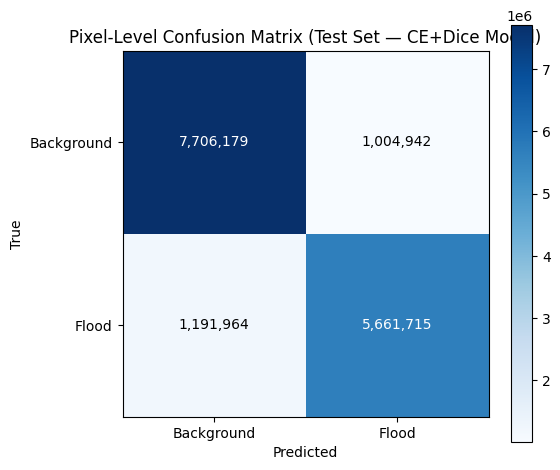

In [45]:
# ============================================================
# Pixel-level confusion matrix
# ============================================================

from sklearn.metrics import confusion_matrix
import itertools

all_true_flat, all_pred_flat = [], []
for images, masks in test_batched:
    preds      = full_unet_dice.predict(images, verbose=0)
    pred_masks = tf.argmax(preds, axis=-1).numpy().flatten()
    true_masks = masks.numpy().squeeze(axis=-1).astype(int).flatten()
    all_true_flat.append(true_masks)
    all_pred_flat.append(pred_masks)

all_true_flat = np.concatenate(all_true_flat)
all_pred_flat = np.concatenate(all_pred_flat)

cm = confusion_matrix(all_true_flat, all_pred_flat, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set(xticks=range(NUM_CLASSES), yticks=range(NUM_CLASSES),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       xlabel='Predicted', ylabel='True',
       title='Pixel-Level Confusion Matrix (Test Set — CE+Dice Model)')

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
            color='white' if cm[i,j] > thresh else 'black', fontsize=10)

plt.tight_layout()
plt.show()